# PagedAttention: OS-Inspired KV-Cache Memory Management

> **Difficulty:** Intermediate | **Time:** ~35 min

As we saw in notebook 00, KV-cache memory grows linearly with sequence length and batch size. In a serving system handling hundreds of concurrent requests, **memory management** becomes the bottleneck — not compute.

The problem: traditional systems pre-allocate **contiguous** memory for each request's KV-cache at the maximum possible sequence length. This leads to severe **internal fragmentation** (allocated but unused memory) and **external fragmentation** (gaps between allocations).

**PagedAttention** (vLLM) borrows the virtual memory concept from operating systems: KV-cache is stored in fixed-size **blocks** (pages), mapped via a **block table**. This eliminates fragmentation and enables memory sharing.

This notebook covers:
1. Memory fragmentation in contiguous allocation
2. Block-based allocation with PagedAttention
3. Block tables and the logical → physical mapping
4. Memory sharing for beam search (copy-on-write)

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "../..")))

from mp_tutorial.inference import (
    PagedKVCacheManager, simulate_contiguous_allocation,
)
from mp_tutorial.inference_viz import draw_memory_map, draw_block_table
from mp_tutorial.formatting import info_box, comparison_table
import warnings
warnings.filterwarnings("ignore", message="Glyph.*missing from font", category=UserWarning)
from mp_tutorial.fonts import configure_cjk_fonts
configure_cjk_fonts()

## 1. The Fragmentation Problem

In traditional serving systems, each request's KV-cache is allocated as a **contiguous** chunk of GPU memory at the **maximum sequence length** (e.g., 2048 tokens). Even if a request only generates 50 tokens, the full 2048-token space is reserved.

This creates two types of waste:
- **Internal fragmentation**: allocated memory within a request that's never used
- **External fragmentation**: gaps between allocations that are too small for new requests

Contiguous allocation (max_seq_len=10):
  Requests: 4, each reserves 10 slots
  Total reserved: 40/40 slots
  Actually used:  18/40 slots
  Internal waste: 22 slots (55%)


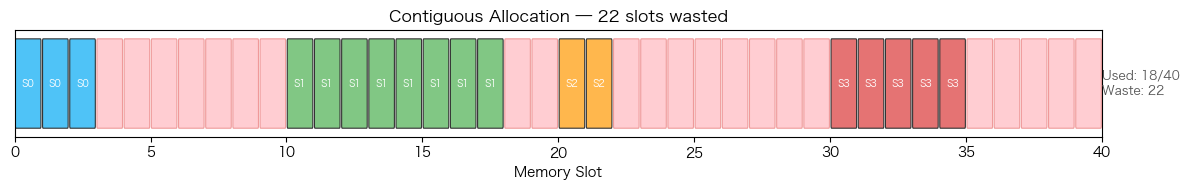

In [2]:
# Simulate contiguous allocation with varied sequence lengths
sequences = [
    (0, 3),   # Request 0: uses 3 tokens
    (1, 8),   # Request 1: uses 8 tokens
    (2, 2),   # Request 2: uses 2 tokens
    (3, 5),   # Request 3: uses 5 tokens
]
max_seq_len = 10  # each request reserves 10 slots
total_memory = 40  # total memory slots

mem_map, waste, allocated = simulate_contiguous_allocation(
    sequences, total_memory, max_seq_len
)

total_used = sum(actual for _, (_, _, actual) in allocated.items())
total_reserved = sum(reserved for _, (_, reserved, _) in allocated.items())

print(f"Contiguous allocation (max_seq_len={max_seq_len}):")
print(f"  Requests: {len(sequences)}, each reserves {max_seq_len} slots")
print(f"  Total reserved: {total_reserved}/{total_memory} slots")
print(f"  Actually used:  {total_used}/{total_memory} slots")
print(f"  Internal waste: {total_reserved - total_used} slots ({(total_reserved - total_used)/total_reserved:.0%})")

fig, ax = draw_memory_map(mem_map, title=f"Contiguous Allocation — {waste} slots wasted")
plt.show()

---
## 2. PagedAttention: Block-Based Allocation

PagedAttention divides KV-cache memory into fixed-size **blocks** (typically 16 tokens each). Each request's KV-cache is stored as a list of blocks, tracked by a **block table** (analogous to an OS page table).

| OS Concept | PagedAttention Equivalent |
|------------|-------------------------|
| Virtual page | Logical KV-cache position |
| Physical frame | Physical memory block |
| Page table | Block table |
| Page fault | Allocate new block on demand |

Blocks are allocated **on demand** — a request only uses memory for tokens it has actually generated.

In [3]:
# Create a PagedAttention block manager
manager = PagedKVCacheManager(num_blocks=16, block_size=4)

# Allocate sequences and add tokens
manager.allocate_sequence(seq_id=0)
for _ in range(3):  # Sequence 0: 3 tokens
    manager.append_token(seq_id=0)

manager.allocate_sequence(seq_id=1)
for _ in range(8):  # Sequence 1: 8 tokens → needs 2 blocks
    manager.append_token(seq_id=1)

manager.allocate_sequence(seq_id=2)
for _ in range(2):  # Sequence 2: 2 tokens
    manager.append_token(seq_id=2)

manager.allocate_sequence(seq_id=3)
for _ in range(5):  # Sequence 3: 5 tokens → needs 2 blocks
    manager.append_token(seq_id=3)

# Show block tables
print("Block tables (logical → physical):")
for seq_id in range(4):
    table = manager.get_block_table(seq_id)
    print(f"  Seq {seq_id}: blocks {table}")

used, total, util = manager.memory_usage()
print(f"\nMemory: {used}/{total} blocks used ({util:.0%})")
print(f"Wasted: 0 blocks (allocation is exact!)")

Block tables (logical → physical):
  Seq 0: blocks [0]
  Seq 1: blocks [1, 2]
  Seq 2: blocks [3]
  Seq 3: blocks [4, 5]

Memory: 6/16 blocks used (38%)
Wasted: 0 blocks (allocation is exact!)


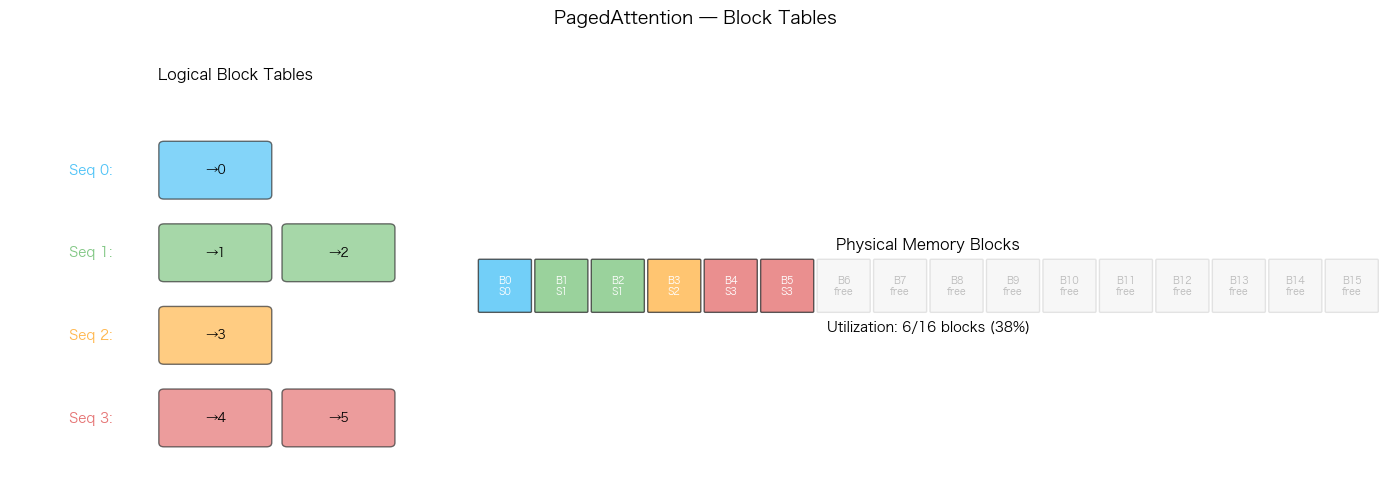

In [4]:
# Visualize block tables and physical memory layout
fig, axes = draw_block_table(manager, title="PagedAttention — Block Tables")
plt.show()

In [5]:
# Compare: same workload with contiguous vs paged allocation
# Contiguous: 4 sequences × max_len=10 = 40 slots reserved
# Paged: only used tokens + partial block overhead

actual_tokens = [3, 8, 2, 5]
max_seq_len = 10
block_size = 4

contiguous_reserved = len(actual_tokens) * max_seq_len
contiguous_used = sum(actual_tokens)
contiguous_waste = contiguous_reserved - contiguous_used

import math
paged_blocks = sum(math.ceil(t / block_size) for t in actual_tokens)
paged_reserved = paged_blocks * block_size
paged_waste = paged_reserved - contiguous_used

print(f"{'Metric':<25} | {'Contiguous':>12} | {'Paged':>12}")
print("-" * 55)
print(f"{'Total tokens':<25} | {contiguous_used:>12} | {contiguous_used:>12}")
print(f"{'Memory reserved':<25} | {contiguous_reserved:>12} | {paged_reserved:>12}")
print(f"{'Waste (slots)':<25} | {contiguous_waste:>12} | {paged_waste:>12}")
print(f"{'Waste %':<25} | {contiguous_waste/contiguous_reserved:>11.0%} | {paged_waste/paged_reserved:>11.0%}")
print(f"{'Utilization':<25} | {contiguous_used/contiguous_reserved:>11.0%} | {contiguous_used/paged_reserved:>11.0%}")

Metric                    |   Contiguous |        Paged
-------------------------------------------------------
Total tokens              |           18 |           18
Memory reserved           |           40 |           24
Waste (slots)             |           22 |            6
Waste %                   |         55% |         25%
Utilization               |         45% |         75%


---
## 3. Dynamic Growth: Allocate on Demand

With PagedAttention, blocks are allocated **only when needed**. As a sequence grows, new blocks are allocated one at a time. When a sequence finishes, its blocks return to the free pool immediately.

Step-by-step allocation:

Allocated seq 0 and 1: 2 blocks used
Seq 0 grew to 6 tokens: 3 blocks used, table=[0, 2]
Seq 1 grew to 10 tokens: 5 blocks used, table=[1, 3, 4]
Seq 0 freed: 3 blocks used (2 blocks returned)
Seq 2 allocated (4 tokens): 4 blocks used, table=[5]


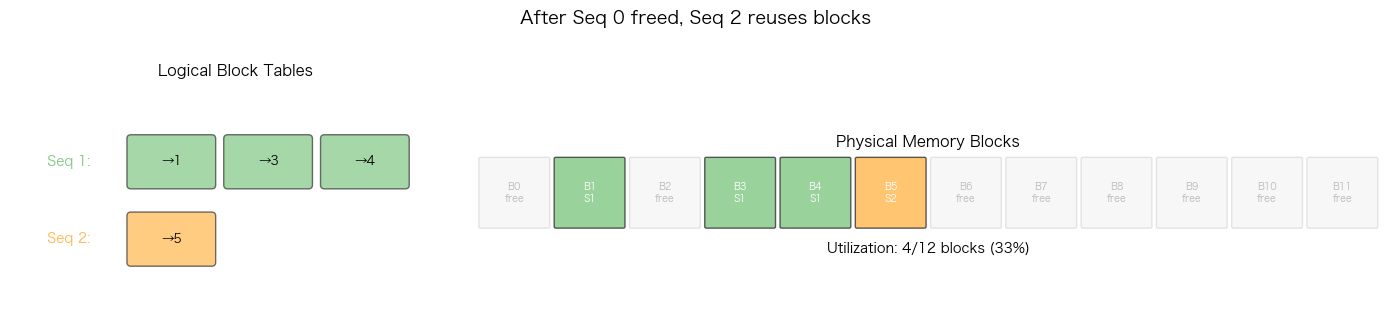

In [6]:
# Watch memory allocation as sequences grow and complete
mgr = PagedKVCacheManager(num_blocks=12, block_size=4)

print("Step-by-step allocation:\n")

# Start two sequences
mgr.allocate_sequence(0)
mgr.allocate_sequence(1)
print(f"Allocated seq 0 and 1: {mgr.memory_usage()[0]} blocks used")

# Grow sequence 0
for i in range(6):
    mgr.append_token(0)
print(f"Seq 0 grew to 6 tokens: {mgr.memory_usage()[0]} blocks used, table={mgr.get_block_table(0)}")

# Grow sequence 1
for i in range(10):
    mgr.append_token(1)
print(f"Seq 1 grew to 10 tokens: {mgr.memory_usage()[0]} blocks used, table={mgr.get_block_table(1)}")

# Sequence 0 completes → free its blocks
mgr.free_sequence(0)
print(f"Seq 0 freed: {mgr.memory_usage()[0]} blocks used (2 blocks returned)")

# New sequence 2 can use the freed blocks
mgr.allocate_sequence(2)
for i in range(4):
    mgr.append_token(2)
print(f"Seq 2 allocated (4 tokens): {mgr.memory_usage()[0]} blocks used, table={mgr.get_block_table(2)}")

fig, axes = draw_block_table(mgr, seq_ids=[1, 2], title="After Seq 0 freed, Seq 2 reuses blocks")
plt.show()

---
## 4. Memory Sharing: Beam Search with Copy-on-Write

In **beam search**, multiple candidate sequences share a common prefix. With contiguous allocation, each beam must copy the entire KV-cache. With PagedAttention, beams **share blocks** for the common prefix and only allocate new blocks where they diverge.

This uses **copy-on-write** semantics: shared blocks have a reference count > 1. When a beam needs to modify a shared block, a copy is made first.

In [7]:
# Simulate beam search with shared prefix
mgr_beam = PagedKVCacheManager(num_blocks=20, block_size=4)

# Original sequence: 8 tokens of shared prefix
mgr_beam.allocate_sequence(seq_id=0)
for _ in range(8):
    mgr_beam.append_token(seq_id=0)

print(f"Original sequence (8 tokens): blocks {mgr_beam.get_block_table(0)}")
print(f"Memory used: {mgr_beam.memory_usage()[0]} blocks\n")

# Fork into 4 beams (beam search with beam_width=4)
for beam_id in range(1, 5):
    mgr_beam.fork_sequence(src_seq_id=0, new_seq_id=beam_id)

print("After forking into 4 beams (copy-on-write):")
for beam_id in range(5):
    table = mgr_beam.get_block_table(beam_id)
    print(f"  Beam {beam_id}: blocks {table}")

print(f"\nMemory used: {mgr_beam.memory_usage()[0]} blocks")
print(f"Without sharing: would need {5 * 3} blocks (5 beams × 3 blocks each)")
print(f"With sharing: only {mgr_beam.memory_usage()[0]} blocks (shared prefix!)")

# Each beam generates a different continuation
for beam_id in range(1, 5):
    for _ in range(3):  # each beam generates 3 more tokens
        mgr_beam.append_token(beam_id)

print(f"\nAfter each beam generates 3 more tokens:")
for beam_id in range(1, 5):
    print(f"  Beam {beam_id}: blocks {mgr_beam.get_block_table(beam_id)}")
print(f"Memory used: {mgr_beam.memory_usage()[0]} blocks")

Original sequence (8 tokens): blocks [0, 1]
Memory used: 2 blocks

After forking into 4 beams (copy-on-write):
  Beam 0: blocks [0, 1]
  Beam 1: blocks [0, 1]
  Beam 2: blocks [0, 1]
  Beam 3: blocks [0, 1]
  Beam 4: blocks [0, 1]

Memory used: 2 blocks
Without sharing: would need 15 blocks (5 beams × 3 blocks each)
With sharing: only 2 blocks (shared prefix!)

After each beam generates 3 more tokens:
  Beam 1: blocks [0, 1, 2]
  Beam 2: blocks [0, 1, 3]
  Beam 3: blocks [0, 1, 4]
  Beam 4: blocks [0, 1, 5]
Memory used: 6 blocks


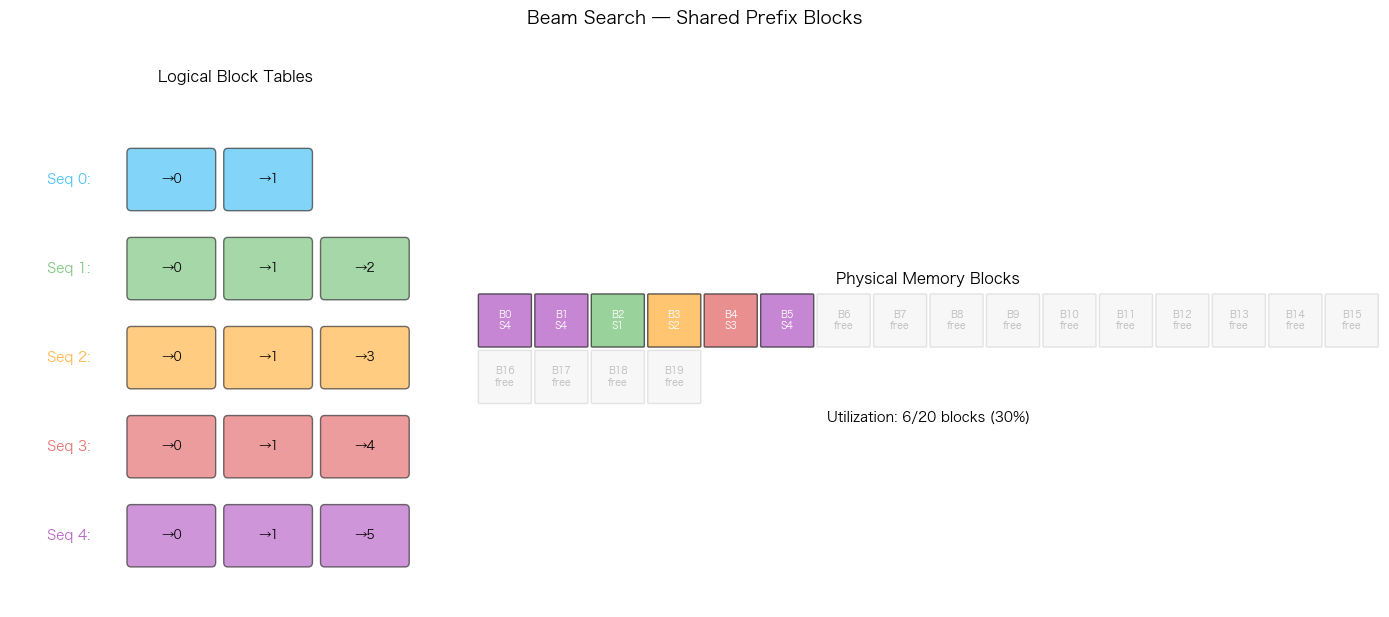

In [8]:
fig, axes = draw_block_table(
    mgr_beam, seq_ids=[0, 1, 2, 3, 4],
    title="Beam Search — Shared Prefix Blocks"
)
plt.show()

---
## 5. vLLM Architecture Overview

vLLM implements PagedAttention within a complete serving system:

```
┌─────────────┐     ┌──────────────┐     ┌──────────────┐
│   Clients    │────▶│   Scheduler   │────▶│   Workers     │
│  (API/HTTP)  │     │  (iteration-  │     │  (GPU model   │
│              │◀────│   level)      │◀────│   execution)  │
└─────────────┘     └──────┬───────┘     └──────────────┘
                           │
                    ┌──────▼───────┐
                    │ Block Manager │
                    │ (allocate,    │
                    │  free, fork)  │
                    └──────────────┘
```

- **Scheduler**: implements continuous batching, decides which requests to run each step
- **Block Manager**: allocates/frees KV-cache blocks, handles copy-on-write
- **Workers**: execute the model with PagedAttention kernels that read KV from non-contiguous blocks via the block table

The custom PagedAttention CUDA kernel reads K/V values by looking up physical block addresses in the block table, rather than assuming contiguous memory.

---
## Summary

| Concept | Contiguous Allocation | PagedAttention |
|---------|----------------------|----------------|
| **Allocation** | Reserve max_seq_len upfront | Allocate blocks on demand |
| **Fragmentation** | High (internal + external) | Near-zero (only last block) |
| **Memory sharing** | Full copy per beam | Copy-on-write via ref counting |
| **Utilization** | ~50-60% typical | ~95%+ |

PagedAttention is the core innovation behind vLLM's 2-4× throughput improvement over traditional serving systems.

### Further Reading
- [Efficient Memory Management for Large Language Model Serving with PagedAttention (Kwon et al., 2023)](https://arxiv.org/abs/2309.06180)
- [vLLM GitHub](https://github.com/vllm-project/vllm)
- Next notebook: **[04-prefix-caching](04-prefix-caching.ipynb)** — reusing KV-cache across requests